<a href="https://colab.research.google.com/github/DanisStepanov/image_processing/blob/main/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961_%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%BE%D0%B1%D1%8A%D0%B5%D0%BA%D1%82%D0%BE%D0%B2_%D0%BD%D0%B0_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Проектная работа №1: Классификация объектов на изображении**

### **Цель:**

Разработать программу на Python, которая принимает на вход фотографию с изображением монет и вычисляет общую сумму денежных средств, отображенных на ней, используя только библиотеку OpenCV и стандартные библиотеки Python.

### **Базовая реализация:**

1. **Сбор изображения:**
   - Используйте камеру или загрузите готовое изображение с монетами для обработки.

2. **Предварительная обработка изображения:**
   - Преобразуйте изображение в оттенки серого.
   - Примените размытие Гаусса для уменьшения шума.
   - Используйте оператор Кэнни для обнаружения краев.

3. **Обнаружение кругов (монет):**
   - Используйте преобразование Хафа для обнаружения кругов на изображении.
   - Получите координаты центров и радиусов обнаруженных кругов (монет).

4. **Классификация монет:**
   - Определите номинал каждой монеты на основе ее радиуса.
   - Установите пороговые значения для радиусов, соответствующие разным номиналам:
     - **Маленький радиус:** 1 рубль.
     - **Средний радиус:** 2 рубля.
     - **Большой радиус:** 5 рублей.

5. **Подсчет общей суммы:**
   - Суммируйте номиналы всех обнаруженных монет.
   - Отобразите общую сумму на изображении или в консоли.

6. **Отображение результатов:**
   - Нарисуйте окружности на изображении вокруг обнаруженных монет.
   - Подпишите рядом с каждой монетой ее номинал.
   - Покажите исходное изображение с отмеченными монетами.
   - Выведите обработанные этапы для визуализации процесса (например, изображение после предварительной обработки, с контурами и т.д.).

### **Требования к реализации:**

- Использовать только библиотеку **OpenCV** и стандартные библиотеки Python (например, **NumPy**).
- Код должен быть хорошо документирован с комментариями для каждого основного блока.
- Предусмотреть возможность настройки параметров обработки через трекбары или отдельные переменные.


### **Рекомендации:**

- **Преобразование Хафа** для кругов является удобным инструментом для обнаружения круглых объектов на изображении.
- **Пороговые значения радиусов** необходимо подобрать экспериментально, протестировав на образцах монет разных номиналов.
- **Обработка перекрывающихся монет** может потребовать более сложных алгоритмов, таких как водоразделение или использование градиентных признаков.
- Тестируйте программу на различных изображениях с разным количеством и расположением монет, а также при разном освещении.

### **Ожидаемый результат:**

В результате выполнения задания вы получите программу, которая способна:

- Принимать на вход изображение с монетами.
- Обрабатывать изображение и обнаруживать монеты без использования библиотеки cvzone.
- Определять номинал каждой монеты на основе ее радиуса или других признаков.
- Вычислять и отображать общую сумму монет на изображении.

---

**Пример использования программы:**

- Пользователь запускает программу.
- Загружается изображение с монетами.
- Программа обрабатывает изображение, отмечает каждую монету и подписывает ее номинал.
- Отображается изображение с результатами и выводится общая сумма, например: **"Общая сумма: 37 рублей"**.

---

**Заметка:**

Данный проект позволит вам:

- Изучить и применить технологии обработки изображений с помощью OpenCV без привлечения сторонних библиотек.
- Научиться решать практические задачи компьютерного зрения, применяя базовые методы и улучшая их по мере необходимости.

---

**Советы по реализации:**

- **Настройка параметров:**
  - Для преобразования Хафа используйте функцию `cv2.HoughCircles()`.
  - Экспериментируйте с параметрами `dp`, `minDist`, `param1`, `param2`, `minRadius`, `maxRadius`.
- **Отображение результатов:**
  - Используйте функцию `cv2.circle()` для рисования окружностей.
  - Для отображения текста воспользуйтесь `cv2.putText()`.
- **Обработка ошибок:**
  - Обрабатывайте случаи, когда преобразование Хафа не обнаруживает ни одной монеты.
  - Предусмотрите проверку входных данных и вывод информативных сообщений для пользователя.



In [1]:
!curl -o coins.jpg https://cdn.monetnik.ru/storage/market-lot/76/49/115676/348662_mainViewLot_2x.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  104k  100  104k    0     0   139k      0 --:--:-- --:--:-- --:--:--  139k


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [18]:
img = cv2.imread('coins.jpg')

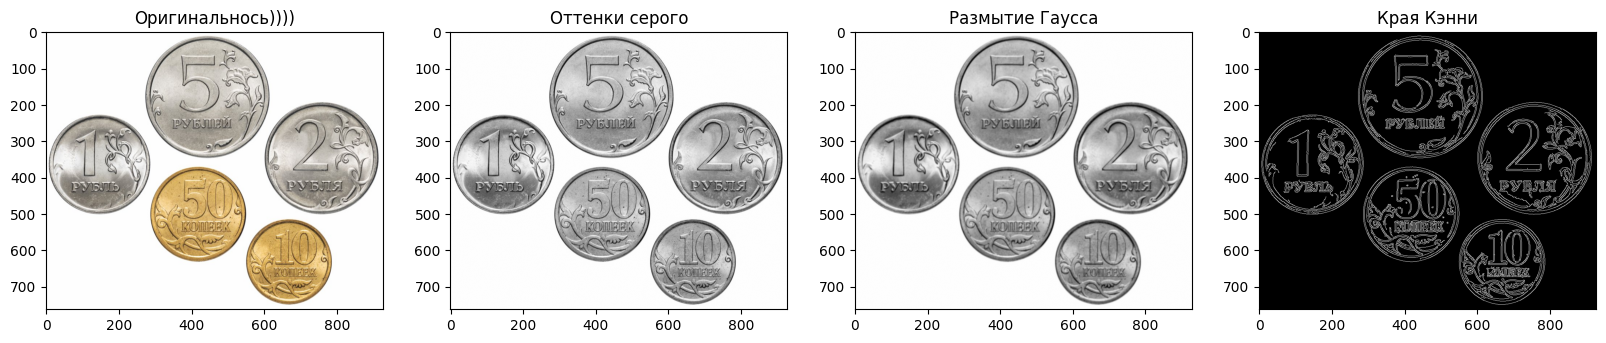

In [30]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(gray_blurred, 50, 150, apertureSize=3)

plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Оригинальнось))))')

plt.subplot(1, 4, 2)
plt.imshow(gray, cmap='gray')
plt.title('Оттенки серого')

plt.subplot(1, 4, 3)
plt.imshow(gray_blurred, cmap='gray')
plt.title('Размытие Гаусса')

plt.subplot(1, 4, 4)
plt.imshow(edges, cmap='gray')
plt.title('Края Кэнни')
plt.show()

In [26]:
# Параметры для функции HoughCircles
dp = 1.2                # Параметр разрешения аккумуляторного массива
minDist = 100            # Минимальное расстояние между центрами обнаруженных окружностей
param1 = 50             # Порог для метода Кэнни
param2 = 150            # Порог для функции HoughCircles (чем меньше, тем больше ложных кругов)
minRadius = 50         # Минимальный радиус круга
maxRadius = 250          # Максимальный радиус круга

# Обнаружение кругов
circles = cv2.HoughCircles(gray_blurred, cv2.HOUGH_GRADIENT, dp, minDist,
                           param1=param1, param2=param2,
                           minRadius=minRadius, maxRadius=maxRadius)

In [27]:
small_radius_max = 150
medium_radius_max = 160
total = 0
coin_values = []
if circles is not None:
    circles = np.uint16(np.around(circles))
    for circle in circles[0, :]:
        radius = int(circle[2])
        if radius < small_radius_max:
            value = 1
        elif radius < medium_radius_max:
            value = 2
        else:
            value = 5
        coin_values.append(value)
        total += value
    print("Найдено монет:", len(coin_values))
    print("Номиналы монет:", coin_values)
    print("Общая сумма:", total, "рублей")

Найдено монет: 5
Номиналы монет: [5, 2, 1, 1, 1]
Общая сумма: 10 рублей


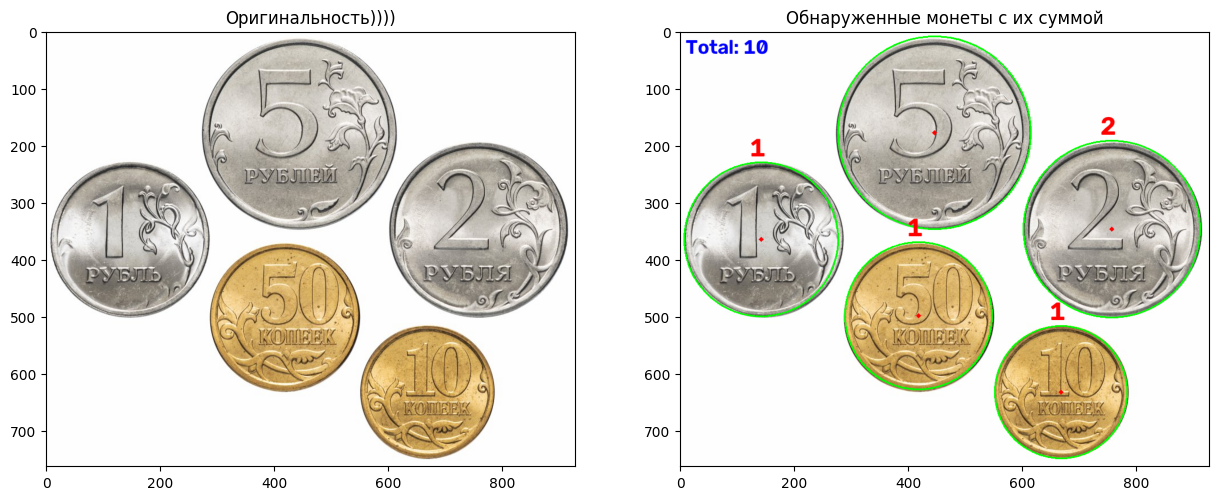

In [29]:
img_circles = img.copy()
if circles is not None:
    for circle, value in zip(circles[0, :], coin_values):
        center = (int(circle[0]), int(circle[1]))
        radius = int(circle[2])
        cv2.circle(img_circles, center, radius, (0, 255, 0), 2)
        cv2.circle(img_circles, center, 2, (0, 0, 255), 3)
        cv2.putText(img_circles, str(value), (center[0] - 20, center[1] - radius - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)
    cv2.putText(img_circles, "Total: " + str(total), (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 0, 0), 3)
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Оригинальность))))')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_circles, cv2.COLOR_BGR2RGB))
plt.title('Обнаруженные монеты с их суммой')
plt.show()